In [ ]:
import numpy as np
import scipy.stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, t
from statsmodels.stats.weightstats import ztest

In [81]:
np.random.seed(1)

In [82]:
# setup mu and sd corresponding to the human heights
mu = 170  # mean height in cm
sd = 7 # standard deviation in cm
n = 100 # number of samples to generate

In [83]:
# generate random samples from gaussian(or normal) distribution
x = norm.rvs(loc=mu, scale=sd, size=n)

In [84]:
# maximum likelihood estimate of mean
x.mean()

np.float64(170.42407996452988)

In [85]:
# maximum likelihood estimate of var
x.var()

np.float64(38.39157462134868)

In [86]:
# check by manually calculating the variance
((x - x.mean()) ** 2).mean()

np.float64(38.39157462134868)

In [87]:
# maximum likelihood estimate of sd
x.std()

np.float64(6.196093496821097)

In [88]:
# unbiased estimate of variance with N-1 degree of freedom
x.var(ddof=1)   # ddof = 1 means N-1 degree of freedom

np.float64(38.779368304392605)

In [89]:
# checking the variance calculation manually
((x - x.mean()) ** 2).sum() / (len(x)-1)  # the difference between the MLE var and unbiased var is the denominator

np.float64(38.779368304392605)

In [90]:
# unbiased estimate of sd with N-1 degree of freedom
x.std(ddof=1)

np.float64(6.227308271186886)

In [91]:
# at what height are you in the 95th percetile?
norm.ppf(0.95, loc=mu, scale=sd)    # ppf is percentile point fundtion that tells the value at a given percentile/probability in a normal distribution
# this means thaf if your height is 181 cm approx, then 95% of the poplation is shorter than you are.

np.float64(181.5139753886603)

In [92]:
# if you are 160 cm tall,what percentile are you in? (Inverse of ppf)
norm.cdf(160, loc=mu, scale=sd)   # cdf is cumulative distribution function that gives the probability of a random variable being less than or equal to a certain value
# this means if you are 160 cm tall, then approx 8% of the population is shorter than you are.

np.float64(0.07656372550983476)

In [93]:
# if you are 180 cm tall, what is the probability that someone is taller than you? (Also called the survival function)
1 - norm.cdf(180, loc=mu, scale=sd)

np.float64(0.07656372550983481)

In [94]:
# calculating the same using the survival function directly
norm.sf(180, loc=mu, scale=sd)

np.float64(0.07656372550983476)

In [95]:
# calculating the end points for t-distribution at 95% confidence interval 
t_left = scipy.stats.t.ppf(0.025, df=n-1)
t_right = scipy.stats.t.ppf(0.975, df=n-1)


CONFIDENCE INTERVAL

In [96]:
np.random.seed(1)

In [ ]:
N = 1000    # number of samples
mu = 5  # true mean
sigma = 2   # true standard deviation
X = np.random.randn(N) * sigma + mu   # generate random samples from a normal distribution using the randn function (inverse of standardization)
                                      # randn generates samples from standard normal distribution (mean = 0, var = 1).
                                      # multiplying by sigma and adding mu transforms the any normal distribution (mean = mu, var = sigma^2)

In [98]:
# Z-confidence interval
mu_hat = np.mean(X)
sigma_hat = np.std(X, ddof=1)
z_left = norm.ppf(0.025)
z_right = norm.ppf(0.975)
lower = mu_hat + z_left * sigma_hat / np.sqrt(N)
upper = mu_hat + z_right * sigma_hat / np.sqrt(N)
print(mu_hat,lower, upper)

5.077624952319204 4.955959806754385 5.199290097884023


In [99]:
# t-confidence interval
mu_hat = np.mean(X)
sigma_hat = np.std(X, ddof=1)
t_left = scipy.stats.t.ppf(0.025, df=N-1)   # unlike the normal distribution,the t-dist requires dof 
t_right = scipy.stats.t.ppf(0.975, df=N-1)
lower = mu_hat + t_left * sigma_hat / np.sqrt(N)
upper = mu_hat + t_right * sigma_hat / np.sqrt(N)
print(mu_hat, lower, upper)

5.077624952319204 4.9558122244324165 5.199437680205992


In [100]:
# Interpretation of confidence intervals
# If we repeat this experiment multiple times, then 95% CI implies that 95% CI should contain the true mean 95% of the time.

# defining the experiment funcion that generates 95% CI and checks if the true mean lies within the interval.
def experiment(N = 1000, mu = 5, sigma = 2):
    X = np.random.randn(N) * sigma + mu
    mu_hat = np.mean(X)
    sigma_hat = np.std(X, ddof=1)
    t_left = scipy.stats.t.ppf(0.025, df=N-1)
    t_right = scipy.stats.t.ppf(0.975, df=N-1)
    lower = mu_hat + t_left * sigma_hat / np.sqrt(N)
    upper = mu_hat + t_right * sigma_hat / np.sqrt(N)
    return mu > lower and mu < upper

In [101]:
# running the experiment M times and calculating the average
def multi_experiment(M):
    results = [experiment() for _ in range(M)]  # underscore represents that the actual loop index is irrelevant
    return np.mean(results)

In [102]:
multi_experiment(10000)

np.float64(0.9506)

Z-Test

One-sample Test

In [103]:
np.random.seed(0)

In [104]:
N = 100
mu = 0.2
sigma = 1
X = np.random.randn(N) * sigma + mu

In [105]:
ztest(X)    # performing 1 sample ztest against the value 0

(np.float64(2.5648404153513686), np.float64(0.01032232684881584))

In [106]:
# replicate the above test using own code
# this is a two-sided test
mu_hat = np.mean(X)
sigma_hat = np.std(X, ddof=1)
z = (mu_hat - 0) / (sigma_hat / np.sqrt(N))    # mu0 (null hypothesis mean) = 0
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left
z, p
# Note: Instead of using the 1 - norm.cdf, we can also use norm.sf, which is the survival function in scipy.

(np.float64(2.564840415351368), np.float64(0.010322326848815901))

In [107]:
# one-sided test (we check for greater than case as the mu_hat is actually greater than 0)
ztest(X, alternative = 'larger')
# Note: the p-value is basically the half or p_right calculated in the above 2-sided test

(np.float64(2.5648404153513686), np.float64(0.00516116342440792))

In [108]:
# replicate the above test using own code
# this is a one-sided test
mu_hat = np.mean(X)
sigma_hat = np.std(X, ddof=1)
z = (mu_hat - 0) / (sigma_hat / np.sqrt(N))
p = 1 - norm.cdf(np.abs(z))
z, p

(np.float64(2.564840415351368), np.float64(0.005161163424407977))

In [109]:
# z-test with a different null hypothesis value
mu0 = 0.2   # the null hypothesis mean is the same as the sample mean (mu0 = mu_hat) => the null hypotheses is true
ztest(X, value = mu0)
# Inference: the p-value is greater than 0.05, so we fail to reject the null hypothesis at 5% significance level.

(np.float64(0.5904283402851699), np.float64(0.5549035151647227))

In [110]:
# replicate the above test using own code
mu_hat = np.mean(X)
sigma_hat = np.std(X, ddof=1)
z = (mu_hat - mu0) / (sigma_hat / np.sqrt(N))  # (sigma_hat / np.sqrt(N)) is the standard error of the mean
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left
z, p


(np.float64(0.5904283402851698), np.float64(0.5549035151647228))

Two-sample Test

In [111]:
# constructing two random samples
N0 = 100
mu0 = 0.2
sigma0 = 1
X0= np.random.randn(N0) * sigma0 + mu0

N1 = 100
mu1 = 0.5
sigma1 = 1
X1 = np.random.randn(N1) * sigma1 + mu1

In [112]:
# two-sample z-test
ztest(X0, X1)   # null hpothesis is that both sample means are same
# Inference: since p-value is greater than 0.05, we fail to reject the null hypthesis even though we know that mu0 and mu1 are different. 
#            The reason for this could be that the sample sizes are small/ the means might not be far enough apart/ the variances could be too large
#            All of the afore-mentioned things contribute to the z-statistic.

(np.float64(-1.1234612344369315), np.float64(0.2612416557056353))

In [113]:
# replicate the above test using own code
mu_hat0 = np.mean(X0)
mu_hat1 = np.mean(X1)
diff_mu_hat = mu_hat1 - mu_hat0
sigma2_hat0 = np.var(X0, ddof=1)    # variance of 0 sample distribution (and not the variance of the mean of 0 sample distribution)
sigma2_hat1 = np.var(X1, ddof=1)    # variance of 1 sample distribution
# we could have also calculated the variance of the "mean" of each sample using "sigma2_hat0 / N0" and "sigma2_hat1 / N1" respectively
SE = np.sqrt(sigma2_hat0 / N0 + sigma2_hat1 / N1)    #std error is the sqrt of sum of variances of the "mean" of both samples. Var of two sample = sigma1^2/n1 + sigma2^2/n2
z = diff_mu_hat / SE  # assuming the null hypothesis mean (or reference value) is 0
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left
z, p
# Note: In two-sample test, we have individual variances and standard deviations for both samples. 
#       But when combining the two, we get variance of the "mean" of both samples and the standard error.

(np.float64(1.1234612344369315), np.float64(0.26124165570563523))

Type I error or False Alarm

In [ ]:
# we show that we reject the null hypothesis 5% of the times even when it is true. This is called Type I error or False Alarm.
num_tests = 10000
results = np.zeros(num_tests)
for i in range(num_tests):
    x1 = np.random.randn(100)
    x2 = np.random.randn(100)
    z, p = ztest(x1, x2)
    results[i] = p < 0.05

print(results.mean())
# Inference: approximately 5% of the test results are significant (i.e.reject the null hypothesis) even when the null hypothesis is true.

0.0123


Working with real-world data to perform Z-test

In [ ]:
!wget https://lazyprogrammer.me/course_files/titanic_train.csv

--2026-01-28 01:29:19--  https://lazyprogrammer.me/course_files/titanic_train.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 2606:4700:3030::ac43:d5a6, 2606:4700:3031::6815:17d2, 104.21.23.210, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|2606:4700:3030::ac43:d5a6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61194 (60K) [text/csv]
Saving to: ‘titanic_train.csv’

titanic_train.csv   100%[===================>]  59.76K   133KB/s    in 0.4s    

2026-01-28 01:29:20 (133 KB/s) - ‘titanic_train.csv’ saved [61194/61194]



In [124]:
df = pd.read_csv('titanic_train.csv')

In [ ]:
df.head()
# we are interested in knowing the passengers who survived and those who did not survive. The factors of interest can be age, gender, far etc.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [129]:
# when passengers survived
df[df['Survived'] == 1].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [131]:
# our goal is to check the difference in the fare of the survival and non-survival groups.
# we'll call x1 as the passengers who survived and x2 as the passengers who did not survive.
x1 = df[df["Survived"] == 1]["Fare"].dropna().to_numpy()
x2 = df[df["Survived"] == 0]["Fare"].dropna().to_numpy()

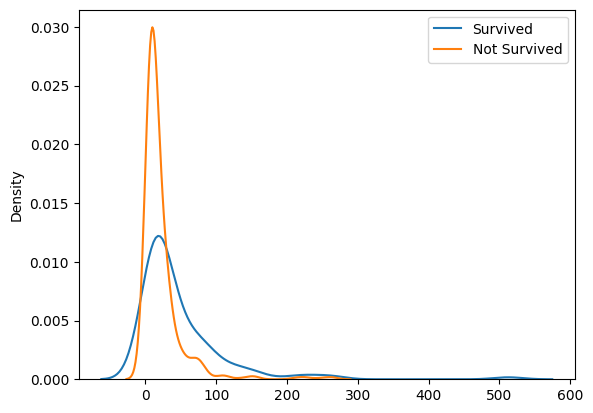

In [133]:
# plot density of fare of both groups
sns.kdeplot(x1, label = "Survived")
sns.kdeplot(x2, label = "Not Survived")
plt.legend()

In [134]:
x1.mean(), x2.mean()

(np.float64(48.39540760233918), np.float64(22.117886885245902))

In [ ]:
ztest(x1, x2)
# Inference: since the p-values is extremely small, we reject the H0 that the mean fare of the two groups is same.

(np.float64(7.939191660871055), np.float64(2.035031103573989e-15))